# Portfolio project 1

## Project Links

**GitHub repository:**  
https://github.com/simoneviktoriaeide/IND320_Simone_Eide

## 1. Importing necessary libraries

In [40]:
import pandas as pd # Imports pandas for data manipulation and analysis
import matplotlib.pyplot as plt  # Imports plotting tools
from matplotlib.ticker import MultipleLocator # Tool to make y axis more detailed here

## 2. Data Exploration

In [2]:
df_raw = pd.read_csv("../data/reservoirs.csv") # Reads the reservoirs.csv file
display(df_raw.head())                         # Displays the five first rows in csv file
display(df_raw.shape)                          # Displays the number of rows and columns


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


(14877, 11)

In [3]:
df_raw.info() # Displays column data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


### Initial Observations

- The dataset has 14,877 rows and 11 columns.
- Date columns are now stored as object and not datetime.
- No missing values were detected.
- The first five rows are not sorted chronologically which we have to consider changing

The dates should be converted and the data sorted before visualization.

## 3. Data Preparation

In [4]:
display(df_raw.columns)  # Displays the current column names

Index(['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad',
       'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato',
       'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad'],
      dtype='str')

In [5]:
df = df_raw.copy()  # Creates a working copy of the original dataset

In [6]:
df = df.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_fill_level",
    "endring_fyllingsgrad": "fill_level_change"
})  # Renames columns to clear and consistent English names

In [7]:
print("Original column names:") 
display(df_raw.columns)        # Displays original names of columns

print("Renamed column names:") # Displays new english names of columns
display(df.columns)

Original column names:


Index(['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad',
       'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato',
       'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad'],
      dtype='str')

Renamed column names:


Index(['date', 'area_type', 'area_number', 'iso_year', 'iso_week',
       'fill_level', 'capacity_twh', 'stored_energy_twh',
       'next_publication_date', 'previous_week_fill_level',
       'fill_level_change'],
      dtype='str')

### Column Renaming: Observations

The columns were renamed to clear and consistent English names to improve readability.

A separate working copy (df) was used to preserve the original dataset (df_raw). The comparison confirms that all 11 columns were renamed successfully while the original column names remain unchanged.

In [8]:
display(df["date"].head(10)) # Displays the first 10 date values

0    1995-09-03
1    2020-11-15
2    2011-08-28
3    1998-07-05
4    2011-03-27
5    2017-11-05
6    2003-03-02
7    2000-11-26
8    2016-09-04
9    2023-08-13
Name: date, dtype: str

In [9]:
df["date"] = pd.to_datetime(df["date"])  # Converts the date column to datetime

In [10]:
print(df["date"].dtype)  # Displays the data type of the date column

datetime64[us]


### Date Conversion: Observations

The date column was converted from object to datetime64[ns].

The conversion was successful, allowing pandas to handle the values as dates for timeseries analysis and visualization.

In [11]:
print(df["date"].is_monotonic_increasing)  # Checks if dates are sorted chronologically

False


In [12]:
display(df[["area_type"]].drop_duplicates()) # Dispkays the unique area types

,area_type
0,EL
8265,NO
9918,VASS


In [13]:
display(
    df.groupby(["area_type", "area_number"]).size()
)  # Counts records for each area combination

area_type  area_number
EL         1              1653
           2              1653
           3              1653
           4              1653
           5              1653
NO         0              1653
VASS       1              1653
           2              1653
           3              1653
dtype: int64

In [14]:
print(df["date"].nunique())  # Counts the number of unique dates

1653


In [15]:
display(df.groupby("date").size().value_counts())  # Counts how many dates have each number of records

9    1653
Name: count, dtype: int64

In [16]:
print(df.duplicated(subset=["date", "area_type", "area_number"]).sum())  # Counts duplicate date-area combinations

0


### Data Structure: Observations

The dataset contains 1,653 unique dates and 9 area combinations.

Each date has exactly one record per area, with no duplicate date-area combinations.

The areas should be treated as separate time series to avoid misleading visualizations.

In [17]:
print("First date:", df["date"].min())  # Finds the earliest date
print("Last date:", df["date"].max())   # Finds the latest date

First date: 1995-01-08 00:00:00
Last date: 2026-09-06 00:00:00


The dataset covers the period from January 8, 1995, to September 6, 2026.

In [18]:
df = df.sort_values(
    by=["area_type", "area_number", "date"]
).reset_index(drop=True)  # Sorts each area's records chronologically

In [19]:
df.head()

,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level,fill_level_change
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
1,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,0001-01-01T00:00:00,0.621467,-0.038367
2,1995-01-22,EL,1,1995,3,0.550604,6.003264,3.305419,0001-01-01T00:00:00,0.583100,-0.032496
3,1995-01-29,EL,1,1995,4,0.508440,6.003264,3.052297,0001-01-01T00:00:00,0.550604,-0.042164
4,1995-02-05,EL,1,1995,5,0.469223,6.003264,2.816870,0001-01-01T00:00:00,0.508440,-0.039217


In [20]:
display(df[["area_type", "area_number", "date"]].head(10))  # Displays the first 10 sorted records

,area_type,area_number,date
0,EL,1,1995-01-08
1,EL,1,1995-01-15
2,EL,1,1995-01-22
3,EL,1,1995-01-29
4,EL,1,1995-02-05
5,EL,1,1995-02-12
6,EL,1,1995-02-19
7,EL,1,1995-02-26
8,EL,1,1995-03-05
9,EL,1,1995-03-12


In [21]:
print(
    df.groupby(["area_type", "area_number"])["date"]
    .apply(lambda dates: dates.is_monotonic_increasing)
)  # Checks whether dates are chronologically sorted within each area

area_type  area_number
EL         1              True
           2              True
           3              True
           4              True
           5              True
NO         0              True
VASS       1              True
           2              True
           3              True
Name: date, dtype: bool


### Sorting: Observations

The working dataset was sorted by area type, area number, and date.

The validation confirmed that dates are in chronological order within all nine areas. The original dataset remains unchanged.

## 4. Data Visualization: Plotting each column separately

OBS: Some columns are not plotted separately because they are used as identifiers or contain information already represented by other columns.

- `date`, `iso_year`, and `iso_week` describe time. `date` is used as the time axis in the visualizations.
- `area_type` and `area_number` identify the different areas and are used to group the data.
- `next_publication_date` contains publication information and is not relevant for analyzing the reservoir measurements.

The remaining measurement columns are visualized below.

### 4.1 Column: date
date is used as the time axis for the time-series visualizations and is therefore not plotted as a separate measurement.

### 4.2 Column: area_type
`area_type` is a categorical variable used to separate the different area groups and is therefore not plotted as a numerical measurement. Instead, area_type divides the dataset into three different areas before plotting: EL, NO and VASS. This prevents different area types from being mixed in the same visualization and makes the plots easier to interpret.

### 4.3 Column: fill_level

#### EL area, fill_level

<Axes: title={'center': 'Reservoir fill level - EL areas'}, xlabel='Date', ylabel='Fill level'>

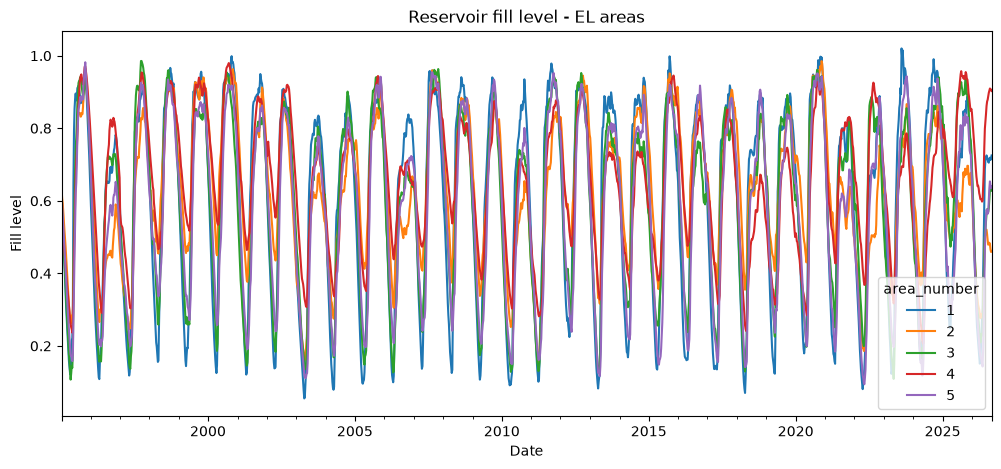

In [22]:
el_df = df[df["area_type"] == "EL"].copy()  # Selects all EL areas

el_pivot = el_df.pivot(
    index="date",
    columns="area_number",
    values="fill_level"
)  # Creates one column per EL area

el_pivot.plot(
    figsize=(12, 5),
    title="Reservoir fill level - EL areas",
    xlabel="Date",
    ylabel="Fill level"
)

#### VASS area, fill_level

<Axes: title={'center': 'Reservoir fill level - VASS areas'}, xlabel='Date', ylabel='Fill level'>

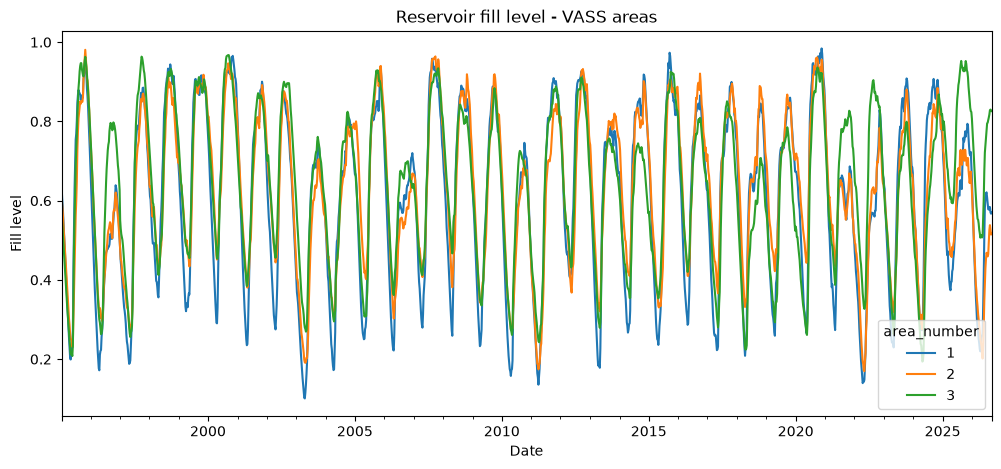

In [23]:
vass_df = df[df["area_type"] == "VASS"].copy()  # Selects all VASS areas

vass_pivot = vass_df.pivot(
    index="date",
    columns="area_number",
    values="fill_level"
)  # Creates one column per VASS area

vass_pivot.plot(
    figsize=(12, 5),
    title="Reservoir fill level - VASS areas",
    xlabel="Date",
    ylabel="Fill level"
)

#### NO area

<Axes: title={'center': 'Reservoir fill level - NO'}, xlabel='Date', ylabel='Fill level'>

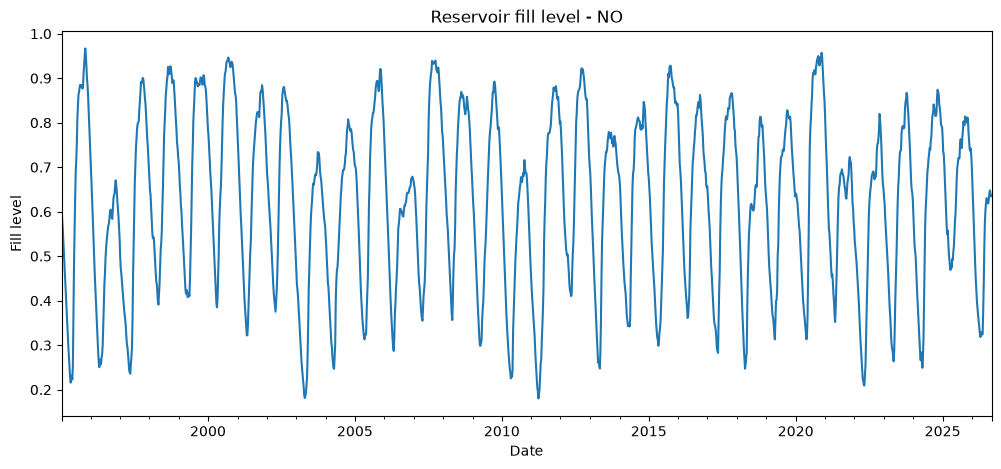

In [24]:
no_df = df[df["area_type"] == "NO"].copy()  # Selects all NO observations

no_df.plot(
    x="date",
    y="fill_level",
    figsize=(12, 5),
    title="Reservoir fill level - NO",
    xlabel="Date",
    ylabel="Fill level",
    legend=False
)

#### fill_level - Analysis

The different areas show similar recurring patterns in reservoir fill level over time.

The `EL` and `VASS` areas represent different regional divisions of the same Norwegian reservoir system. `EL` divides the data according to Norway's five electricity price areas, while `VASS` uses three reservoir areas based on groups of river systems. `NO` represents Norway as a whole.

The national fill level therefore reflects total stored energy relative to total reservoir capacity in Norway, rather than a simple average of the individual areas.

Although the areas generally follow the same overall pattern, regional differences in fill level can be observed over time.

### 4.4 Column: capacity_twh

In [25]:
# Checks how many unique capacity values each area has
display(
    df.groupby(["area_type", "area_number"])["capacity_twh"].nunique()
)

area_type  area_number
EL         1              1
           2              1
           3              1
           4              1
           5              1
NO         0              1
VASS       1              1
           2              1
           3              1
Name: capacity_twh, dtype: int64

The reservoir capacity of each area remains constant throughout the dataset from 1995 to 2026. However, the total capacity differs between individual areas.

<Axes: title={'center': 'Reservoir capacity by area'}, xlabel='Area', ylabel='Capacity (TWh)'>

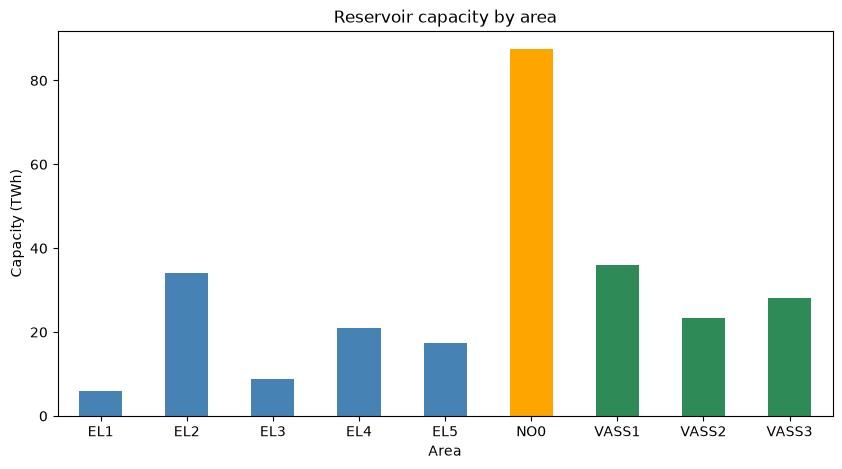

In [26]:
# Selects one capacity value for each area since it is constant
capacity = (
    df.groupby(["area_type", "area_number"])["capacity_twh"]
    .first()
    .reset_index()
)

# Creates labels such as EL1, NO0 and VASS1
capacity["area"] = (
    capacity["area_type"] + capacity["area_number"].astype(str)
)

# Assigns one color to each area type
colors = capacity["area_type"].map({
    "EL": "steelblue",
    "NO": "orange",
    "VASS": "seagreen"
})

# Compares reservoir capacity across all areas
capacity.plot(
    x="area",
    y="capacity_twh",
    kind="bar",
    color=colors,
    figsize=(10, 5),
    title="Reservoir capacity by area",
    xlabel="Area",
    ylabel="Capacity (TWh)",
    legend=False,
    rot=0
)

The total capacity is approximately the same when the reservoirs are grouped by `EL`, `VASS`, or `NO`. Checking this statement under:

In [27]:
# Compares total capacity for each area type
display(
    df.groupby(["area_type", "area_number"])["capacity_twh"]
      .first()
      .groupby("area_type")
      .sum()
)

area_type
EL      87.437581
NO      87.437580
VASS    87.437582
Name: capacity_twh, dtype: float64

Observation:

Reservoir capacity is constant over time within each area.

The total capacity is approximately 87.44 TWh for each area type. NO represents the total capacity, while EL and VASS divide approximately the same total capacity into five and three areas, respectively.

The three area types therefore represent different groupings of the reservoir capacity and should not be added together.

### 4.5 Column: stored_energy_twh

In [28]:
# Calculates total stored energy for each area type and date
stored_energy_totals = (
    df.groupby(["date", "area_type"])["stored_energy_twh"]
    .sum()
    .unstack()
)

display(stored_energy_totals.head())

area_type,EL,NO,VASS
date,,,
1995-01-08,53.085099,53.185986,53.035549
1995-01-15,50.836736,50.921207,50.799090
1995-01-22,49.116507,49.175980,49.057868
1995-01-29,46.697492,46.736122,46.633492
1995-02-05,44.267742,44.285900,44.211534


#### El area

<Axes: title={'center': 'Stored energy – EL areas'}, xlabel='Date', ylabel='Stored energy (TWh)'>

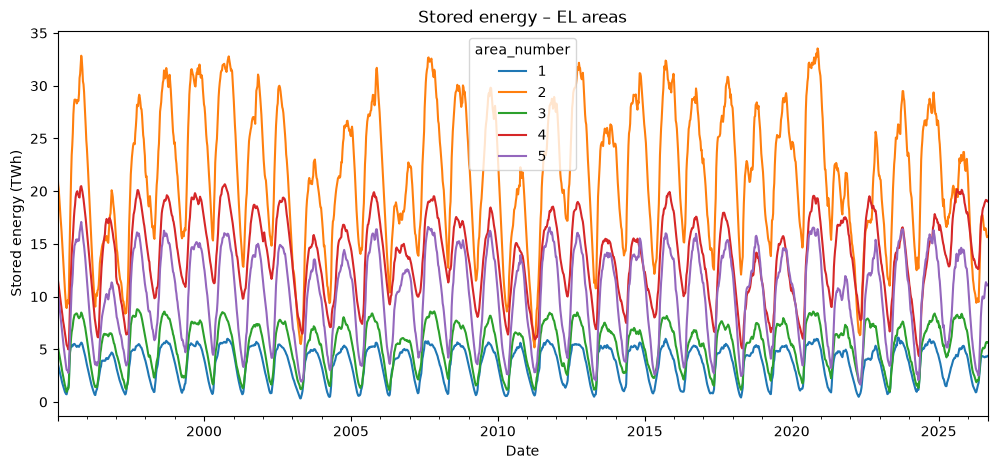

In [29]:
# Creates one stored energy column per EL area
el_energy = el_df.pivot(
    index="date",
    columns="area_number",
    values="stored_energy_twh"
)

# Plots stored energy over time for all five EL areas
el_energy.plot(
    figsize=(12, 5),
    title="Stored energy – EL areas",
    xlabel="Date",
    ylabel="Stored energy (TWh)"
)

Stored energy varies over time and shows recurring seasonal patterns.
EL area 2 has the highest stored energy, consistent with its larger
reservoir capacity.

#### VASS area, stored_energy_twh

<Axes: title={'center': 'Stored energy - VASS areas'}, xlabel='Date', ylabel='Stored energy (TWh)'>

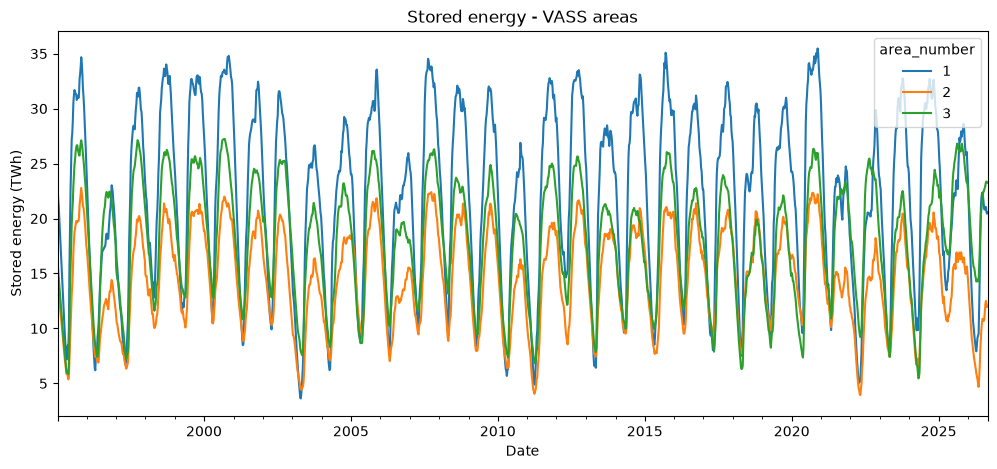

In [30]:
# Creates one stored energy column per VASS area
vass_energy = vass_df.pivot(
    index="date",
    columns="area_number",
    values="stored_energy_twh"
)

# Plots stored energy over time for all three VASS areas
vass_energy.plot(
    figsize=(12, 5),
    title="Stored energy - VASS areas",
    xlabel="Date",
    ylabel="Stored energy (TWh)"
)

#### NO area, stored_energy_twh

<Axes: title={'center': 'Stored energy - NO'}, xlabel='Date', ylabel='Stored energy (TWh)'>

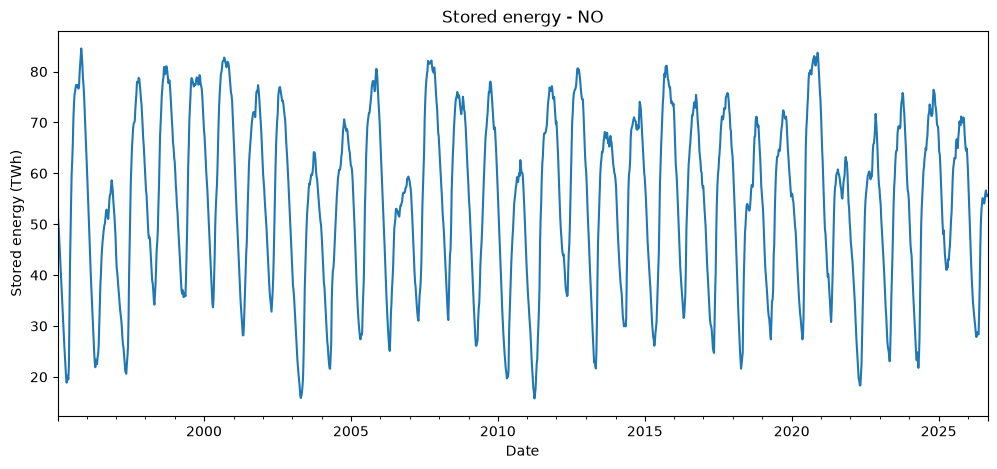

In [31]:
# Plots stored energy over time for NO
no_df.plot(
    x="date",
    y="stored_energy_twh",
    figsize=(12, 5),
    title="Stored energy - NO",
    xlabel="Date",
    ylabel="Stored energy (TWh)",
    legend=False
)

### 4.6 Column: previous_week_fill_level

`previous_week_fill_level` shows the fill level from the previous week. It is not plotted separately because it would be very similar to `fill_level`.

### 4.7 Column: fill_level_change

#### EL-area, fill_level_change

<Axes: title={'center': 'Change in fill level - EL areas'}, xlabel='Date', ylabel='Change in fill level'>

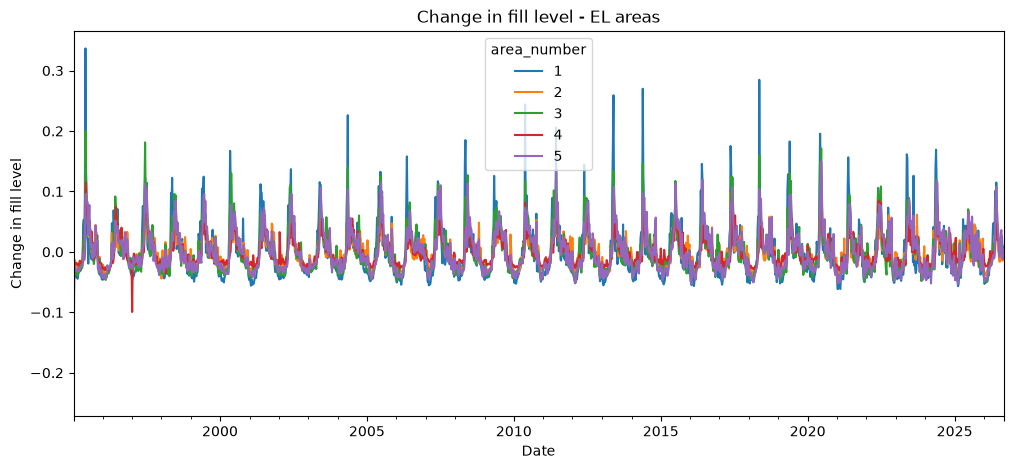

In [32]:
# Creates one fill level change column per EL area
el_fill_change = el_df.pivot(
    index="date",
    columns="area_number",
    values="fill_level_change"
)

# Plots the weekly change for all EL areas
el_fill_change.plot(
    figsize=(12, 5),
    title="Change in fill level - EL areas",
    xlabel="Date",
    ylabel="Change in fill level"
)

#### VASS area, fill_level_change

<Axes: title={'center': 'Change in fill level - VASS areas'}, xlabel='Date', ylabel='Change in fill level'>

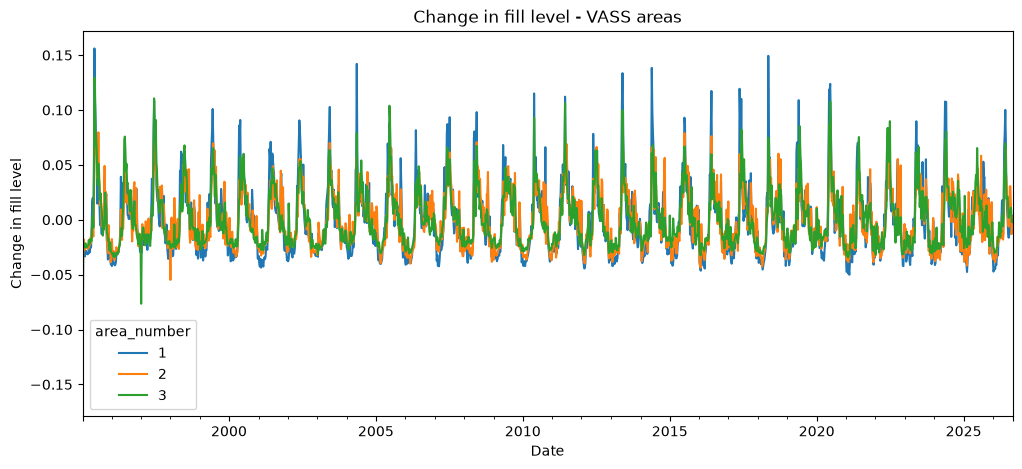

In [33]:
# Creates one fill level change column per VASS area
vass_fill_change = vass_df.pivot(
    index="date",
    columns="area_number",
    values="fill_level_change"
)

# Plots the weekly change for all VASS areas
vass_fill_change.plot(
    figsize=(12, 5),
    title="Change in fill level - VASS areas",
    xlabel="Date",
    ylabel="Change in fill level"
)

In [34]:
# Calculates the variation in weekly fill level change for each VASS area
vass_change_stats = (
    df[df["area_type"] == "VASS"]
    .groupby("area_number")["fill_level_change"]
    .agg(["mean", "std", "min", "max"])
)

display(vass_change_stats)

,mean,std,min,max
area_number,,,,
1,-0.000138,0.032845,-0.162787,0.156077
2,-0.000138,0.025811,-0.135837,0.089191
3,0.000099,0.025859,-0.094525,0.129572


Vass area 1 seems to have more variation in changes than the other vass areas.

In [35]:
# Calculates yearly variation in fill level change for each VASS area
vass_yearly_variation = (
    df[df["area_type"] == "VASS"]
    .groupby(["iso_year", "area_number"])["fill_level_change"]
    .std()
    .unstack()
)

display(vass_yearly_variation)

area_number,1,2,3
iso_year,,,
1995,0.046357,0.037632,0.039008
1996,0.025584,0.021572,0.029058
1997,0.032312,0.025258,0.034068
1998,0.027890,0.025557,0.024956
1999,0.032544,0.024875,0.023934
2000,0.033023,0.023542,0.025112
2001,0.033895,0.024413,0.021952
2002,0.033424,0.025110,0.024099
2003,0.030168,0.023416,0.023787


<Axes: title={'center': 'Yearly variation in fill level change - VASS areas'}, xlabel='Year', ylabel='Standard deviation'>

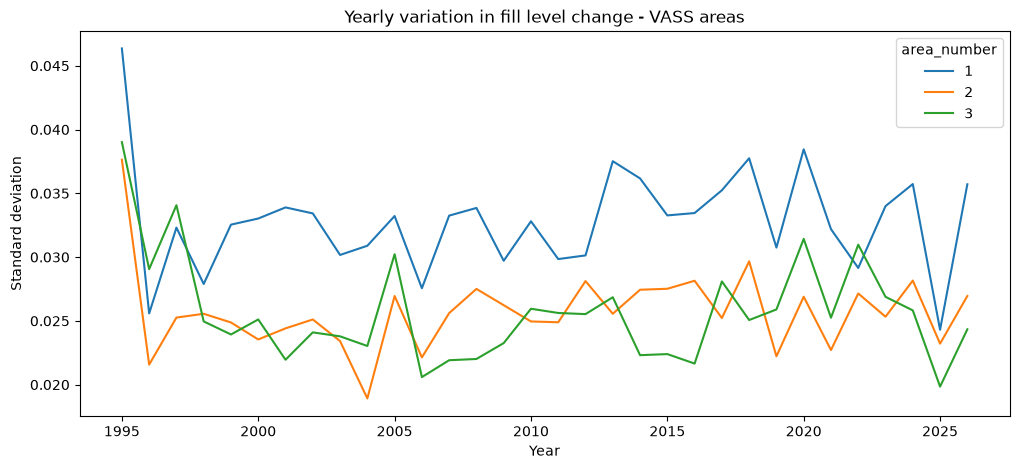

In [36]:
# Plots yearly variation in weekly fill level change for each VASS area
vass_yearly_variation.plot(
    figsize=(12, 5),
    xlabel="Year",
    ylabel="Standard deviation",
    title="Yearly variation in fill level change - VASS areas"
)

Yearly variation - VASS areas:

VASS1 shows higher year-to-year variation in weekly fill level changes than VASS2 and VASS3 in most years. This supports the pattern observed for the full dataset and suggests that the higher variation in VASS1 is not caused only by a few extreme years.

However, VASS1 does not have the highest variation every year, and the differences between the areas change over time. This shows that reservoir dynamics vary both between regions and between years.

#### NO area, fill_level_change

<Axes: title={'center': 'Change in fill level - NO'}, xlabel='Date', ylabel='Change in fill level'>

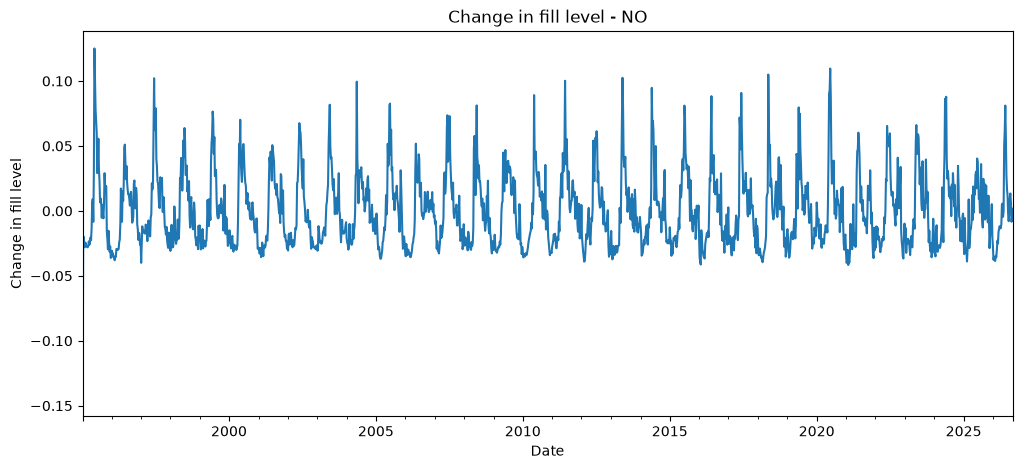

In [37]:
# Plots the weekly change in fill level for NO
no_df.plot(
    x="date",
    y="fill_level_change",
    figsize=(12, 5),
    title="Change in fill level - NO",
    xlabel="Date",
    ylabel="Change in fill level",
    legend=False
)

#### Fill level change - Observations for all areas

The fill level change fluctuates around zero. Positive values show an increase in fill level, while negative values show a decrease.

## 5. Data Visualization - Plotting Combined Columns

The national NO data is used to focus on the relationship between the measurements (columns) without mixing the different regional classifications. For more details on each region, see Streamlit page 3. 

Since the columns represents measurments of different scales, I have chosen to use percentage as y axis. This is due to information being lost if we use a different scale. By using percentage, we are able to keep all of the information from each column in the plot. 



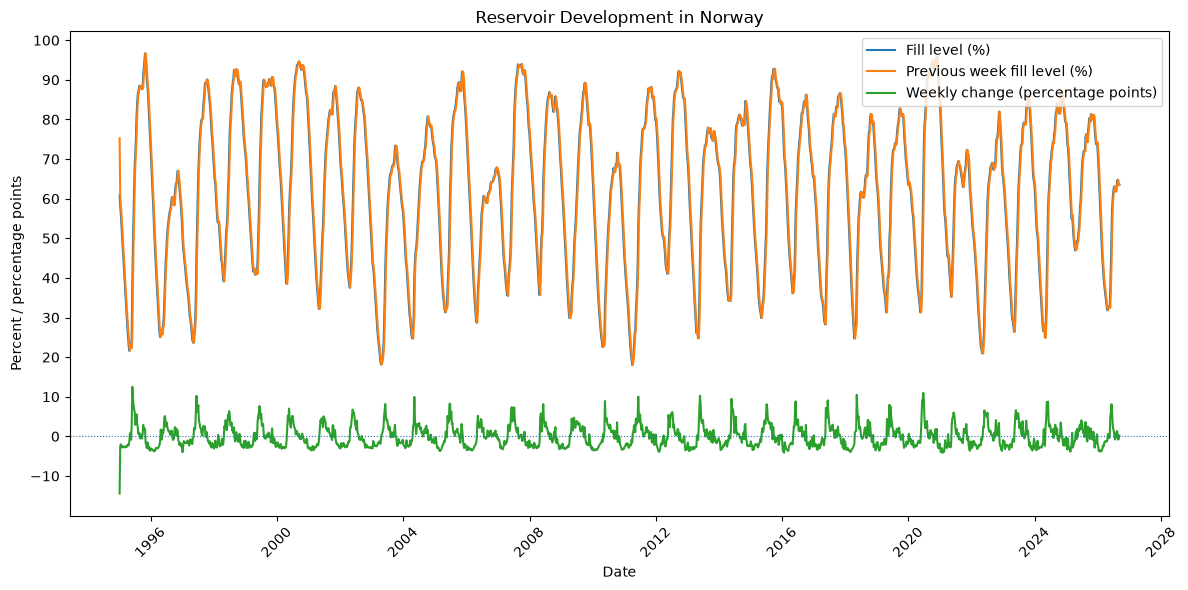

In [41]:
# Select national reservoir data
no_data = df[df["area_type"] == "NO"].copy()
no_data = no_data.sort_values("date")

# Convert reservoir levels to percent and weekly change to percentage points
fill_level = no_data["fill_level"] * 100
previous_week = no_data["previous_week_fill_level"] * 100
weekly_change = no_data["fill_level_change"] * 100

# Create the combined plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    no_data["date"],
    fill_level,
    label="Fill level (%)"
)

ax.plot(
    no_data["date"],
    previous_week,
    label="Previous week fill level (%)"
)

ax.plot(
    no_data["date"],
    weekly_change,
    label="Weekly change (percentage points)"
)

# Add a reference line at zero for weekly change
ax.axhline(
    y=0,
    linewidth=0.8,
    linestyle=":"
)

ax.set_title("Reservoir Development in Norway")
ax.set_xlabel("Date")
ax.set_ylabel("Percent / percentage points")

ax.legend()
ax.yaxis.set_major_locator(MultipleLocator(10))

plt.xticks(rotation=45)
fig.tight_layout()

plt.show()

This graph is not as informative as I wished for because fill level and previous week will look the same because the time interval is 30 years. Would be more informative if looking closer in smaller timeintervals. (Good to know when working in streamlit)